# Data Understanding

In [1]:
from pathlib import Path
import hashlib
import re
import io

import numpy as np
import pandas as pd
import requests
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 120)
sns.set_style('whitegrid')


In [2]:
CSV_PATH = Path('../data/images_dataset/listing_images.csv')
RAW_DIR = Path('../data/images_dataset/raw')
PROC_DIR = Path('../data/images_dataset/processed_224')
MANIFEST_OUT = Path('../data/images_dataset/listing_images_manifest_preprocessed.csv')

TARGET_SIZE = (224, 224)
MAX_DOWNLOAD = 1000          # set lower/higher based on your bandwidth
TIMEOUT_SEC = 12
HEADERS = {"User-Agent": "EstateMind-ImagePipeline/1.0"}

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
df = pd.read_csv(CSV_PATH)
print('shape:', df.shape)
display(df.head(5))
display(df.info())

shape: (1660, 6)


,listing_url,image_url,image_index,source_csv,source_row,city
0,https://www.tecnocasa.tn/vendre/appartement/bizerte/bizerte/45686.html,https://cdn-media.medialabtc.it/tn/agencies/bzco1/estates/45686/images/227753/detail.jpeg,1,data\csv\tecnocasa_real_estate_listings_all.csv,54,Bizerte
1,https://www.tecnocasa.tn/vendre/appartement/bizerte/bizerte/48999.html,https://cdn-media.medialabtc.it/tn/agencies/bzco1/estates/48999/images/272294/gallery_media.jpeg,1,data\csv\tecnocasa_real_estate_listings_all.csv,32,Bizerte
2,https://www.tecnocasa.tn/vendre/appartement/bizerte/bizerte/48999.html,https://cdn-media.medialabtc.it/tn/agencies/bzco1/estates/48999/images/272294/detail.jpeg,2,data\csv\tecnocasa_real_estate_listings_all.csv,32,Bizerte
3,https://www.tecnocasa.tn/vendre/appartement/bizerte/bizerte/51008.html,https://cdn-media.medialabtc.it/tn/agencies/bzco1/estates/51008/images/253572/detail.jpeg,1,data\csv\tecnocasa_real_estate_listings_all.csv,57,Bizerte
4,https://www.tecnocasa.tn/vendre/appartement/bizerte/bizerte/51865.html,https://cdn-media.medialabtc.it/tn/agencies/bzco1/estates/51865/images/271906/detail.jpeg,1,data\csv\tecnocasa_real_estate_listings_all.csv,58,Bizerte


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1660 entries, 0 to 1659
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   listing_url  1660 non-null   object
 1   image_url    1660 non-null   object
 2   image_index  1660 non-null   int64 
 3   source_csv   1660 non-null   object
 4   source_row   1660 non-null   int64 
 5   city         1660 non-null   object
dtypes: int64(2), object(4)
memory usage: 77.9+ KB


None

In [4]:
required_cols = ['listing_url', 'image_url', 'image_index', 'source_csv', 'source_row', 'city']
missing_cols = [c for c in required_cols if c not in df.columns]
print('missing columns:', missing_cols)
assert not missing_cols, f'Missing required columns: {missing_cols}'

quality = {
    'rows': len(df),
    'duplicate_rows_ratio': df.duplicated().mean(),
    'missing_listing_url_ratio': df['listing_url'].isna().mean(),
    'missing_image_url_ratio': df['image_url'].isna().mean(),
    'missing_city_ratio': df['city'].isna().mean(),
    'unique_listings': df['listing_url'].nunique(dropna=True),
    'unique_image_urls': df['image_url'].nunique(dropna=True),
}
quality


missing columns: []


{'rows': 1660,
 'duplicate_rows_ratio': np.float64(0.0),
 'missing_listing_url_ratio': np.float64(0.0),
 'missing_image_url_ratio': np.float64(0.0),
 'missing_city_ratio': np.float64(0.0),
 'unique_listings': 1359,
 'unique_image_urls': 1660}

count    1359.000000
mean        1.221486
std         0.415400
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: n_images, dtype: float64


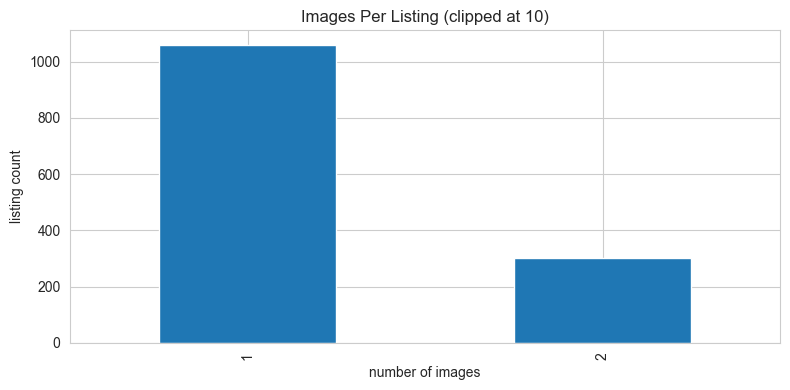

In [5]:
# Distribution: images per listing
images_per_listing = df.groupby('listing_url', dropna=True).size().rename('n_images')
print(images_per_listing.describe())

plt.figure(figsize=(8, 4))
images_per_listing.clip(upper=10).value_counts().sort_index().plot(kind='bar')
plt.title('Images Per Listing (clipped at 10)')
plt.xlabel('number of images')
plt.ylabel('listing count')
plt.tight_layout()
plt.show()


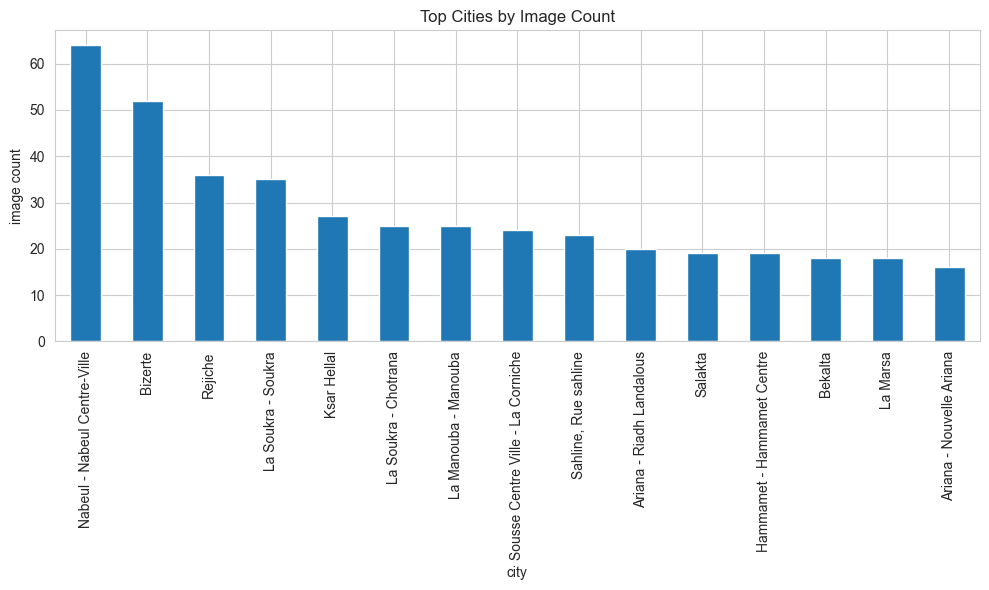

In [6]:
# Top cities by image count
plt.figure(figsize=(10, 6))
(df['city'].fillna('Unknown').value_counts().head(15)).plot(kind='bar')
plt.title('Top Cities by Image Count')
plt.xlabel('city')
plt.ylabel('image count')
plt.tight_layout()
plt.show()


In [7]:
def make_image_id(url: str, idx: int) -> str:
    h = hashlib.sha1(url.encode('utf-8')).hexdigest()[:16]
    return f"{h}_{int(idx):02d}"


def pick_extension_from_url(url: str) -> str:
    m = re.search(r'\.(jpg|jpeg|png|webp)(?:\?|$)', url.lower())
    if m:
        ext = m.group(1)
        return '.jpg' if ext == 'jpeg' else f'.{ext}'
    return '.jpg'


def download_image(url: str) -> bytes | None:
    try:
        r = requests.get(url, timeout=TIMEOUT_SEC, headers=HEADERS)
        if r.status_code == 200 and r.content:
            return r.content
        return None
    except Exception:
        return None


def load_image_from_any(path_or_url: str) -> Image.Image | None:
    p = Path(path_or_url)
    if p.exists() and p.is_file():
        try:
            return Image.open(p)
        except Exception:
            return None

    # fallback: treat as URL
    data = download_image(path_or_url)
    if data is None:
        return None
    try:
        return Image.open(io.BytesIO(data))
    except UnidentifiedImageError:
        return None
    except Exception:
        return None


def preprocess_pil_image(img: Image.Image, size=(224, 224)) -> Image.Image:
    # keep pipeline simple and deterministic for model input prep
    return img.convert('RGB').resize(size)


In [8]:
work = df.copy()
work['image_index'] = pd.to_numeric(work['image_index'], errors='coerce').fillna(1).astype(int)

records = []
for i, row in work.head(MAX_DOWNLOAD).iterrows():
        image_ref = str(row['image_url'])
        idx = int(row['image_index'])

        image_id = make_image_id(image_ref, idx)
        ext = pick_extension_from_url(image_ref)

        raw_path = RAW_DIR / f"{image_id}{ext}"
        proc_path = PROC_DIR / f"{image_id}.jpg"

        status = 'ok'
        width = np.nan
        height = np.nan

        # Skip network/download work if we already have this image in the dataset.
        if proc_path.exists() or raw_path.exists():
            # status = 'already_exists'
            img = Image.open(proc_path if proc_path.exists() else raw_path)
            width, height = img.size
            img.close()
        else:
            # Try local path first (if user stores local paths in image_url), else URL download.
            img = load_image_from_any(image_ref)

            if img is None:
                status = 'download_or_open_failed'
            else:
                try:
                    width, height = img.size
                    # Save raw image only if source is URL and raw file not already present
                    if image_ref.lower().startswith('http') and not raw_path.exists():
                        data = download_image(image_ref)
                        if data is not None:
                            raw_path.write_bytes(data)

                    proc = preprocess_pil_image(img, TARGET_SIZE)
                    proc.save(proc_path, format='JPEG', quality=92)
                except Exception:
                    status = 'preprocess_failed'

        records.append({
            'listing_url': row.get('listing_url'),
            'image_url': image_ref,
            'image_index': idx,
            'city': row.get('city'),
            'source_csv': row.get('source_csv'),
            'source_row': row.get('source_row'),
            'image_id': image_id,
            'raw_path': str(raw_path),
            'processed_path': str(proc_path),
            'orig_width': width,
            'orig_height': height,
            'target_width': TARGET_SIZE[0],
            'target_height': TARGET_SIZE[1],
            'status': status,
        })

manifest = pd.DataFrame(records)
manifest.to_csv(MANIFEST_OUT, index=False)
print('saved manifest:', MANIFEST_OUT)
manifest['status'].value_counts(dropna=False)


saved manifest: ..\data\images_dataset\listing_images_manifest_preprocessed.csv


status
ok                         997
download_or_open_failed      3
Name: count, dtype: int64

In [9]:
# Basic report
report = {
    'input_rows': int(len(df)),
    'processed_attempted': int(len(manifest)),
    'ok_rows': int((manifest['status'] == 'ok').sum()),
    'failed_rows': int((manifest['status'] != 'ok').sum()),
    'ok_ratio': float((manifest['status'] == 'ok').mean()) if len(manifest) else 0.0,
    'unique_processed_files': int(manifest.loc[manifest['status'] == 'ok', 'processed_path'].nunique()),
}
report


{'input_rows': 1660,
 'processed_attempted': 1000,
 'ok_rows': 997,
 'failed_rows': 3,
 'ok_ratio': 0.997,
 'unique_processed_files': 997}

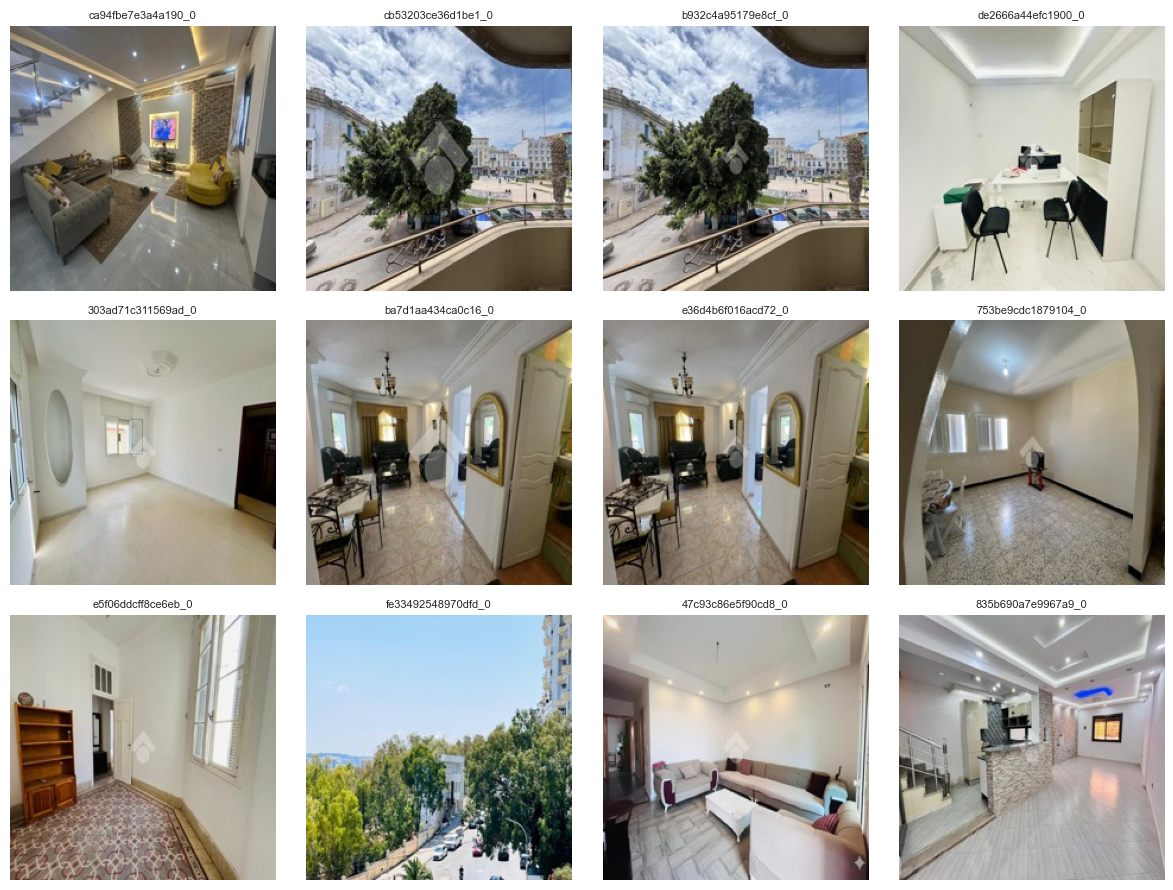

In [10]:
# Visual check: show a few preprocessed images
ok_paths = manifest.loc[manifest['status'] == 'ok', 'processed_path'].head(12).tolist()

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()
for ax, p in zip(axes, ok_paths):
    try:
        img = Image.open(p)
        ax.imshow(img)
        ax.set_title(Path(p).name[:18], fontsize=8)
        ax.axis('off')
    except Exception:
        ax.axis('off')
for j in range(len(ok_paths), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


In [11]:
# Split into train/val/test by listing_url to avoid leakage (same listing across splits)
from sklearn.model_selection import train_test_split

ok_manifest = manifest[manifest['status'] == 'ok'].copy()
print('OK rows:', len(ok_manifest))

# Split by listing_url to avoid leakage (same listing across train/val/test)
unique_listings = ok_manifest['listing_url'].dropna().unique()
print('Unique listings:', len(unique_listings))

train_listings, temp_listings = train_test_split(unique_listings, test_size=0.30, random_state=42)
val_listings, test_listings = train_test_split(temp_listings, test_size=0.50, random_state=42)

train_df = ok_manifest[ok_manifest['listing_url'].isin(train_listings)].copy()
val_df = ok_manifest[ok_manifest['listing_url'].isin(val_listings)].copy()
test_df = ok_manifest[ok_manifest['listing_url'].isin(test_listings)].copy()

print('train/val/test rows:', len(train_df), len(val_df), len(test_df))
print('train/val/test unique listings:', train_df['listing_url'].nunique(), val_df['listing_url'].nunique(), test_df['listing_url'].nunique())

split_dir = Path('../data/images_dataset/splits')
split_dir.mkdir(parents=True, exist_ok=True)
train_df.to_csv(split_dir / 'train_manifest.csv', index=False)
val_df.to_csv(split_dir / 'val_manifest.csv', index=False)
test_df.to_csv(split_dir / 'test_manifest.csv', index=False)
print('Saved split manifests to', split_dir)


OK rows: 997
Unique listings: 821
train/val/test rows: 699 152 146
train/val/test unique listings: 574 123 124
Saved split manifests to ..\data\images_dataset\splits


In [ ]:
# Enrich image splits with structured targets, then build property-type labels for CV training
record_mapping_candidates = [
    Path('../data/csv/final_listings_wrangled_enriched.csv'),
    Path('../data/csv/final_listings_wrangled.csv'),
]
mapping_path = next((p for p in record_mapping_candidates if p.exists()), None)
if mapping_path is None:
    raise FileNotFoundError(f'Could not find a record-id mapping dataset in: {record_mapping_candidates}')

mapping_df = pd.read_csv(mapping_path, low_memory=False)
mapping_required = {'listing_url', 'record_id'}
mapping_missing = mapping_required - set(mapping_df.columns)
if mapping_missing:
    raise ValueError(f'record-id mapping dataset is missing required columns: {mapping_missing}')

mapping_df['listing_url'] = mapping_df['listing_url'].astype(str).str.strip()
mapping_df['record_id'] = mapping_df['record_id'].astype(str).str.strip()
mapping_df = mapping_df.dropna(subset=['listing_url', 'record_id']).copy()
mapping_df = mapping_df.drop_duplicates('listing_url', keep='last')
record_map = mapping_df[['listing_url', 'record_id']]

structured_candidates = [
    Path('../data/csv/preprocessed/final_listings_preprocessed.csv'),
    Path('../data/csv/final_listings_wrangled_enriched.csv'),
    Path('../data/csv/final_listings_wrangled.csv'),
]
structured_path = next((p for p in structured_candidates if p.exists()), None)
if structured_path is None:
    raise FileNotFoundError(f'Could not find any structured dataset in: {structured_candidates}')

tab = pd.read_csv(structured_path, low_memory=False)
join_key = 'record_id'
required = {join_key, 'price_tnd', 'property_type'}
missing = required - set(tab.columns)
if missing:
    raise ValueError(f'structured dataset is missing required columns: {missing}')

tab[join_key] = tab[join_key].astype(str).str.strip()
tab['price_tnd'] = pd.to_numeric(tab['price_tnd'], errors='coerce')
tab['property_type'] = tab['property_type'].astype(str).str.strip()
tab = tab.dropna(subset=[join_key, 'price_tnd', 'property_type']).copy()
tab = tab.sort_values('price_tnd').drop_duplicates(join_key, keep='last')
tab = tab[[join_key, 'price_tnd', 'property_type']]

def resolve_processed_path(path_like):
    path = Path(path_like)
    candidates = [path]
    if not path.is_absolute():
        candidates.extend([
            Path('notebooks') / path,
            Path('..') / path,
            Path.cwd() / path,
            Path.cwd().parent / path,
        ])
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists():
            return candidate
    return path.resolve()

def normalize_property_type(value):
    text = str(value).strip().lower()
    if text in {'terrain', 'land', 'lot'}:
        return 'Terrain'
    if text in {'maison', 'house', 'villa'}:
        return 'Maison'
    if text in {'appartement', 'apartment', 'flat'}:
        return 'Appartement'
    return ''

def attach_targets(split_df):
    if 'listing_url' not in split_df.columns:
        raise ValueError(f"'listing_url' not found in split dataframe columns: {split_df.columns.tolist()}")

    merged = split_df.copy()

    # Make the cell safe to rerun by removing old enrichment columns first.
    stale_cols = ['record_id', 'price_tnd', 'property_type', 'target']
    merged = merged.drop(columns=[c for c in stale_cols if c in merged.columns], errors='ignore')

    merged['listing_url'] = merged['listing_url'].astype(str).str.strip()
    merged = merged.merge(record_map, on='listing_url', how='left', validate='m:1')
    merged[join_key] = merged[join_key].astype(str).str.strip()
    merged = merged.merge(tab, on=join_key, how='left', validate='m:1')

    merged['price_tnd'] = pd.to_numeric(merged['price_tnd'], errors='coerce')
    merged['property_type'] = merged['property_type'].map(normalize_property_type)
    merged = merged.dropna(subset=['processed_path', join_key, 'price_tnd']).copy()
    merged = merged[merged['property_type'].astype(bool)].copy()
    merged['processed_path'] = merged['processed_path'].astype(str).map(resolve_processed_path)
    merged = merged[merged['processed_path'].map(lambda p: p.exists())].copy()
    return merged.reset_index(drop=True)

train_df = attach_targets(train_df)
val_df = attach_targets(val_df)
test_df = attach_targets(test_df)

label_map = {'Terrain': 0, 'Maison': 1, 'Appartement': 2}
train_df['target'] = train_df['property_type'].map(label_map)
val_df['target'] = val_df['property_type'].map(label_map)
test_df['target'] = test_df['property_type'].map(label_map)

val_df = val_df.dropna(subset=['target']).copy()
test_df = test_df.dropna(subset=['target']).copy()
train_df['target'] = train_df['target'].astype(int)
val_df['target'] = val_df['target'].astype(int)
test_df['target'] = test_df['target'].astype(int)
num_classes = int(train_df['target'].nunique())

print('Record-id mapping source:', mapping_path)
print('Structured labels source:', structured_path)
print('join key:', join_key)
print('train/val/test rows after target merge:', len(train_df), len(val_df), len(test_df))
print('num_classes:', num_classes)
print('label_map:', label_map)
print('train class distribution:', train_df['property_type'].value_counts().to_dict())

Record-id mapping source: ..\data\csv\final_listings_wrangled_enriched.csv
Structured labels source: ..\data\csv\preprocessed\final_listings_preprocessed.csv
join key: record_id
train/val/test rows after price merge: 675 143 141
num_classes: 3
price bin edges: [35000.0, 243999.99999999988, 380000.0, 8763600.0]


In [28]:
# Augmentation pipeline aligned with src/train_cnn.py
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_tfms = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.06,
        scale_limit=0.1,
        rotate_limit=10,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.4,
    ),
    A.Normalize(mean=imagenet_mean, std=imagenet_std),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=imagenet_mean, std=imagenet_std),
    ToTensorV2(),
])

c:\Users\ASUS\Desktop\Projects\EstateMind\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
try:
    import torch
    from torch.utils.data import Dataset, DataLoader
except Exception as e:
    torch = None
    print('PyTorch not available:', e)

if torch is None:
    raise ImportError('PyTorch is required to build the CNN loaders in this notebook.')

import cv2
import numpy as np

class ListingImageDataset(Dataset):
    """Dataset wrapper around the processed image manifest.

    Each item returns:
    - image tensor
    - integer class label (`target`)
    - lightweight metadata for analysis/reporting
    """

    def __init__(self, manifest_df, transforms=None):
        """Initialize dataset from a manifest DataFrame.

        Args:
            manifest_df: DataFrame containing at least `processed_path` and `target`.
            transforms: Optional Albumentations transform pipeline.
        """
        self.df = manifest_df.reset_index(drop=True).copy()
        self.transforms = transforms

    def __len__(self):
        """Return the number of rows available for sampling."""
        return len(self.df)

    def __getitem__(self, idx):
        """Load one sample by index and apply preprocessing.

        Raises:
            FileNotFoundError: If the image file cannot be read by OpenCV.
        """
        row = self.df.iloc[idx]
        img_path = row["processed_path"]

        image_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if image_bgr is None:
            raise FileNotFoundError(f'Failed to read image: {img_path}')
        image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        if self.transforms is not None:
            image = self.transforms(image=image)["image"]
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0 #type: ignore[call-overload] 

        y = torch.tensor(int(row["target"]), dtype=torch.long) #type: ignore[call-overload] 

        meta = {
            "listing_url": row.get("listing_url"),
            "city": row.get("city"),
            "image_id": row.get("image_id"),
            "price_tnd": float(row.get("price_tnd", np.nan)),
        }
        return image, y, meta

train_ds = ListingImageDataset(train_df, transforms=train_tfms)
val_ds   = ListingImageDataset(val_df, transforms=val_tfms)
test_ds  = ListingImageDataset(test_df, transforms=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

xb, yb, mb = next(iter(train_loader))
print(xb.shape, yb.shape, list(mb.keys()))
print('classes in train split:', sorted(train_df['target'].unique().tolist()))
print('sample metadata:', {k: v[:3] for k, v in mb.items()})

torch.Size([32, 3, 224, 224]) torch.Size([32]) ['listing_url', 'city', 'image_id', 'price_tnd']
classes in train split: [0, 1, 2]
sample metadata: {'listing_url': ['https://www.tecnocasa.tn/vendre/appartement/grand-tunis/gammarth/54427.html', 'https://www.tecnocasa.tn/vendre/appartement/sousse/sousse-riadh/60974.html', 'https://www.tecnocasa.tn/vendre/appartement/grand-tunis/el-mourouj/57723.html'], 'city': ['Gammarth', 'Sousse Riadh, Rue Japan - Cité Riadh', 'El Mourouj - El Mourouj 6'], 'image_id': ['b29bf504a0beba22_01', '2f6fc05e1cea330e_02', 'dfca663e534d4466_02'], 'price_tnd': tensor([1000000.,   98000.,  280000.], dtype=torch.float64)}


## CNN Benchmark Section Documentation
This section trains and compares three image classifiers on the prepared loaders: ResNet50, EfficientNet-B0, and EfficientNetV2-S.

### Goal
Select the best model checkpoint for the image property-type task (Terrain, Maison, Appartement) using validation quality, then export reproducible artifacts.

### Inputs expected from previous cells
- `train_loader`, `val_loader`, `test_loader` built from leakage-safe listing splits.
- `num_classes` inferred from the property-type label map.
- Working directories under `../artifacts/models/image_benchmark_notebook`.

### Training strategy
- Uses transfer learning (`pretrained=True`) with frozen backbones and trainable classifier heads.
- Optimizer: AdamW.
- Loss: CrossEntropyLoss.
- Model selection rule: highest `val_f1_macro`, then highest `val_acc`, then lowest `f1_gap` (train-val).

### Outputs produced
- Per-model histories: `<model>_history.csv`
- Per-model predictions: `<model>_test_predictions.csv`
- Per-model reports: `<model>_classification_report.json`
- Per-model checkpoints: `checkpoints/<model>_best.pt`
- Global summary: `benchmark_summary.csv`
- Selected model checkpoint: `best_model.pt`
- Selection metadata: `best_model_summary.json`

### Fit diagnostics
The benchmark labels each run as:
- `underfitting`: both train and validation accuracy remain low.
- `overfitting`: train-validation gap is high.
- `balanced`: neither underfitting nor overfitting triggers.

In [ ]:
# CNN benchmark logic adapted from src/train_cnn.py and run on the loaders above
import copy
import json
import time
from dataclasses import dataclass

import timm
import torch.nn as nn
from sklearn.metrics import classification_report, f1_score
from torchvision.models import EfficientNet_B0_Weights, ResNet50_Weights, efficientnet_b0, resnet50

@dataclass
class ModelConfig:
    """Configuration container for one CNN backbone run."""
    name: str
    num_classes: int
    pretrained: bool = True
    freeze_backbone: bool = True
    dropout: float = 0.2

class BaseConvNet(nn.Module):
    """Base wrapper that standardizes model creation and backbone freezing."""

    def __init__(self, cfg: ModelConfig):
        """Construct model and optionally freeze non-classifier parameters."""
        super().__init__()
        self.cfg = cfg
        self.model = self._create_model(cfg)
        if cfg.freeze_backbone:
            self._freeze_backbone()

    def _create_model(self, cfg: ModelConfig):
        """Create and return a backbone-specific nn.Module."""
        raise NotImplementedError

    def _classifier_module(self):
        """Return the classifier head module used for fine-tuning."""
        raise NotImplementedError

    def _freeze_backbone(self):
        """Freeze all parameters except those in the classifier head."""
        for p in self.model.parameters():
            p.requires_grad = False
        for p in self._classifier_module().parameters():
            p.requires_grad = True

    def forward(self, x):
        """Run a forward pass through the underlying model."""
        return self.model(x)

class ResNet50Classifier(BaseConvNet):
    """ResNet50 classifier with a dropout + linear custom head."""

    def _create_model(self, cfg: ModelConfig):
        """Instantiate ResNet50 and replace its final FC layer."""
        try:
            weights = ResNet50_Weights.IMAGENET1K_V2 if cfg.pretrained else None
            model = resnet50(weights=weights)
        except Exception:
            model = resnet50(weights=None)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(p=cfg.dropout), nn.Linear(in_features, cfg.num_classes))  # type: ignore[call-overload]
        return model

    def _classifier_module(self):
        """Return ResNet's classifier module for selective training."""
        return self.model.fc

class EfficientNetB0Classifier(BaseConvNet):
    """EfficientNet-B0 classifier with a custom final classifier block."""

    def _create_model(self, cfg: ModelConfig):
        """Instantiate EfficientNet-B0 and replace final classifier layer."""
        try:
            weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if cfg.pretrained else None
            model = efficientnet_b0(weights=weights)
        except Exception:
            model = efficientnet_b0(weights=None)
        in_features = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=cfg.dropout, inplace=True),
            nn.Linear(in_features, cfg.num_classes),  # type: ignore[call-overload]
        )
        return model

    def _classifier_module(self):
        """Return EfficientNet-B0 classifier module for fine-tuning."""
        return self.model.classifier

class EfficientNetV2SClassifier(BaseConvNet):
    """EfficientNetV2-S classifier created through timm."""

    def _create_model(self, cfg: ModelConfig):
        """Instantiate EfficientNetV2-S using timm with fallback to random init."""
        try:
            model = timm.create_model(
                'efficientnetv2_s',
                pretrained=cfg.pretrained,
                num_classes=cfg.num_classes,
                drop_rate=cfg.dropout,
            )
        except Exception:
            model = timm.create_model(
                'efficientnetv2_s',
                pretrained=False,
                num_classes=cfg.num_classes,
                drop_rate=cfg.dropout,
            )
        return model

    def _classifier_module(self):
        """Return classifier submodule exposed by timm model."""
        classifier = self.model.get_classifier()
        return classifier if isinstance(classifier, nn.Module) else self.model

def build_model(cfg: ModelConfig):
    """Factory for supported CNN backbones."""
    model_map = {
        'resnet50': ResNet50Classifier,
        'efficientnet_b0': EfficientNetB0Classifier,
        'efficientnet_v2_s': EfficientNetV2SClassifier,
    }
    if cfg.name not in model_map:
        raise ValueError(f'Unsupported model name: {cfg.name}')
    return model_map[cfg.name](cfg)

class Trainer:
    """Minimal trainer/evaluator used for the architecture benchmark."""

    def __init__(self, model, device, lr=1e-3):
        """Initialize optimizer, criterion, and best-checkpoint tracking."""
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        trainable_params = [p for p in self.model.parameters() if p.requires_grad]
        self.optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)  # type: ignore[call-overload]
        self.best_state = copy.deepcopy(self.model.state_dict())
        self.best_val_f1 = -1.0
        self.best_val_acc = -1.0
        self.best_epoch = 0
        self.history = []

    def _run_one_epoch(self, loader, train):
        """Run one train/eval epoch and return aggregate metrics."""
        self.model.train(mode=train)
        total_loss = 0.0
        y_true, y_pred = [], []

        for xb, yb, _ in loader:
            xb = xb.to(self.device, non_blocking=True)
            yb = yb.to(self.device, non_blocking=True)

            if train:
                self.optimizer.zero_grad(set_to_none=True)

            logits = self.model(xb)
            loss = self.criterion(logits, yb)

            if train:
                loss.backward()
                self.optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            y_true.extend(yb.detach().cpu().tolist())
            y_pred.extend(preds.detach().cpu().tolist())

        avg_loss = total_loss / max(len(loader.dataset), 1)
        acc = float(np.mean(np.array(y_true) == np.array(y_pred))) if y_true else 0.0
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0) if y_true else 0.0
        return {'loss': avg_loss, 'acc': acc, 'f1_macro': float(f1)}

    @torch.no_grad()
    def evaluate(self, loader):
        """Evaluate model on a loader without gradient tracking."""
        return self._run_one_epoch(loader, train=False)

    def fit(self, train_loader, val_loader, epochs=3):
        """Train for a fixed number of epochs and keep best validation checkpoint."""
        for epoch in range(1, epochs + 1):
            tr = self._run_one_epoch(train_loader, train=True)
            va = self.evaluate(val_loader)

            row = {
                'epoch': epoch,
                'train_loss': tr['loss'],
                'train_acc': tr['acc'],
                'train_f1_macro': tr['f1_macro'],
                'val_loss': va['loss'],
                'val_acc': va['acc'],
                'val_f1_macro': va['f1_macro'],
                'acc_gap': tr['acc'] - va['acc'],
                'f1_gap': tr['f1_macro'] - va['f1_macro'],
            }
            self.history.append(row)

            is_better = (
                va['f1_macro'] > self.best_val_f1 or
                (va['f1_macro'] == self.best_val_f1 and va['acc'] > self.best_val_acc)
            )
            if is_better:
                self.best_val_f1 = va['f1_macro']
                self.best_val_acc = va['acc']
                self.best_epoch = epoch
                self.best_state = copy.deepcopy(self.model.state_dict())

            print(
                f"epoch {epoch:02d} | train loss {tr['loss']:.4f} acc {tr['acc']:.4f} f1 {tr['f1_macro']:.4f} | "
                f"val loss {va['loss']:.4f} acc {va['acc']:.4f} f1 {va['f1_macro']:.4f}"
            )

        self.model.load_state_dict(self.best_state)

    @torch.no_grad()
    def predict(self, loader):
        """Run inference and return labels, confidences, and metadata."""
        self.model.eval()
        y_true, y_pred, y_conf, metas = [], [], [], []

        for xb, yb, mb in loader:
            xb = xb.to(self.device, non_blocking=True)
            logits = self.model(xb)
            probs = torch.softmax(logits, dim=1)  # type: ignore[call-overload]
            conf, preds = probs.max(dim=1)

            y_true.extend(yb.tolist())
            y_pred.extend(preds.detach().cpu().tolist())
            y_conf.extend(conf.detach().cpu().tolist())

            batch_size = len(yb)
            for i in range(batch_size):
                metas.append({
                    'listing_url': mb['listing_url'][i],
                    'image_id': mb['image_id'][i],
                    'price_tnd': float(mb['price_tnd'][i]),
                })

        return {'y_true': y_true, 'y_pred': y_pred, 'y_conf': y_conf, 'meta': metas}

def _num_params(model):
    """Return total and trainable parameter counts for a model."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def diagnose_fit(history_df):
    """Classify the run as underfitting, overfitting, or balanced."""
    best_row = history_df.sort_values(['val_f1_macro', 'val_acc'], ascending=False).iloc[0]
    acc_gap = float(best_row['train_acc'] - best_row['val_acc'])
    f1_gap = float(best_row['train_f1_macro'] - best_row['val_f1_macro'])

    if best_row['train_acc'] < 0.60 and best_row['val_acc'] < 0.60:
        fit_status = 'underfitting'
    elif acc_gap > 0.10 or f1_gap > 0.10:
        fit_status = 'overfitting'
    else:
        fit_status = 'balanced'

    return {
        'best_epoch': int(best_row['epoch']),
        'best_train_acc': float(best_row['train_acc']),
        'best_train_f1_macro': float(best_row['train_f1_macro']),
        'best_val_acc': float(best_row['val_acc']),
        'best_val_f1_macro': float(best_row['val_f1_macro']),
        'acc_gap': acc_gap,
        'f1_gap': f1_gap,
        'fit_status': fit_status,
    }

def run_benchmark(train_loader, val_loader, test_loader, num_classes, output_dir, epochs=3, lr=1e-3):
    """Train all candidate backbones and persist benchmark artifacts.

    Returns:
        DataFrame sorted by selection priority (`val_f1_macro`, `val_acc`, `f1_gap`).
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    checkpoints_dir = output_dir / 'checkpoints'
    checkpoints_dir.mkdir(parents=True, exist_ok=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # type: ignore[call-overload]
    print(f'Using device: {device}')

    model_names = ['resnet50', 'efficientnet_b0', 'efficientnet_v2_s']
    results = []
    trainer_states = {}

    for name in model_names:
        print(f'\n=== Training {name} ===')
        cfg = ModelConfig(name=name, num_classes=num_classes, pretrained=True, freeze_backbone=True)
        model = build_model(cfg)
        total_params, trainable_params = _num_params(model)
        trainer = Trainer(model=model, device=device, lr=lr)

        t0 = time.time()
        trainer.fit(train_loader, val_loader, epochs=epochs)
        train_seconds = time.time() - t0

        history_df = pd.DataFrame(trainer.history)
        history_df.to_csv(output_dir / f'{name}_history.csv', index=False)
        diagnosis = diagnose_fit(history_df)

        val_metrics = trainer.evaluate(val_loader)
        test_metrics = trainer.evaluate(test_loader)
        pred_out = trainer.predict(test_loader)

        report = classification_report(
            pred_out['y_true'],
            pred_out['y_pred'],
            output_dict=True,
            zero_division=0,
        )

        preds_df = pd.DataFrame(pred_out['meta'])
        preds_df['y_true'] = pred_out['y_true']
        preds_df['y_pred'] = pred_out['y_pred']
        preds_df['confidence'] = pred_out['y_conf']
        preds_df.to_csv(output_dir / f'{name}_test_predictions.csv', index=False)

        with (output_dir / f'{name}_classification_report.json').open('w', encoding='utf-8') as f:
            json.dump(report, f, indent=2)

        checkpoint_payload = {
            'model_name': name,
            'num_classes': num_classes,
            'state_dict': trainer.best_state,
            'history': trainer.history,
            'diagnosis': diagnosis,
        }
        torch.save(checkpoint_payload, checkpoints_dir / f'{name}_best.pt')
        trainer_states[name] = checkpoint_payload

        results.append({
            'model': name,
            'fit_status': diagnosis['fit_status'],
            'best_epoch': diagnosis['best_epoch'],
            'train_acc_at_best_epoch': diagnosis['best_train_acc'],
            'train_f1_at_best_epoch': diagnosis['best_train_f1_macro'],
            'val_acc': val_metrics['acc'],
            'val_f1_macro': val_metrics['f1_macro'],
            'test_acc': test_metrics['acc'],
            'test_f1_macro': test_metrics['f1_macro'],
            'test_loss': test_metrics['loss'],
            'acc_gap': diagnosis['acc_gap'],
            'f1_gap': diagnosis['f1_gap'],
            'train_seconds': train_seconds,
            'total_params': total_params,
            'trainable_params': trainable_params,
        })

    benchmark_df = pd.DataFrame(results).sort_values(
        ['val_f1_macro', 'val_acc', 'f1_gap'],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    best_model_name = str(benchmark_df.iloc[0]['model'])
    benchmark_df['selected_model'] = benchmark_df['model'].eq(best_model_name)
    benchmark_df.to_csv(output_dir / 'benchmark_summary.csv', index=False)

    best_payload = trainer_states[best_model_name]
    torch.save(best_payload, output_dir / 'best_model.pt')#type: ignore[call-overload]
    with (output_dir / 'best_model_summary.json').open('w', encoding='utf-8') as f:
        json.dump({
            'selected_model': best_model_name,
            'selection_rule': 'highest val_f1_macro, then highest val_acc, then lowest f1_gap',
            'benchmark_rows': benchmark_df.to_dict(orient='records'),
        }, f, indent=2)

    print(f'Selected best model: {best_model_name}')
    print(f'Saved best model checkpoint to: {output_dir / "best_model.pt"}')
    return benchmark_df


In [ ]:
if num_classes < 2:
    raise ValueError(f'Need at least 2 classes, got {num_classes}')

output_dir = Path('../artifacts/models/image_benchmark_notebook')
benchmark_df = run_benchmark(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    output_dir=output_dir,
    epochs=3,
    lr=1e-3,
 )
display(benchmark_df)
print('Saved notebook benchmark artifacts to', output_dir)

# Export fallback artifacts consumed by ImageTypeClassifierService.
import json
import shutil

fallback_model_path = Path('../artifacts/models/image_property_type_fallback.pt')
fallback_labels_path = Path('../artifacts/models/image_property_type_fallback.labels.json')
fallback_model_path.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(output_dir / 'best_model.pt', fallback_model_path)

id_to_property_type = {idx: name for name, idx in label_map.items()}
classes = [
    {
        'id': idx,
        'label': id_to_property_type[idx].lower(),
        'description': f'Notebook fallback property-type class: {id_to_property_type[idx]}',
    }
    for idx in sorted(id_to_property_type.keys())
]

fallback_labels_payload = {
    'model_name': str(benchmark_df.iloc[0]['model']),
    'label_space': 'property_type',
    'classes': classes,
}
fallback_labels_path.write_text(json.dumps(fallback_labels_payload, indent=2), encoding='utf-8')

print('Exported fallback model to', fallback_model_path)
print('Exported fallback labels to', fallback_labels_path)

Using device: cpu

=== Training resnet50 ===
epoch 01 | train loss 1.0866 acc 0.3585 f1 0.3582 | val loss 1.0511 acc 0.4825 f1 0.4608
epoch 02 | train loss 1.0026 acc 0.5067 f1 0.5063 | val loss 1.0626 acc 0.4266 f1 0.3955
epoch 03 | train loss 0.9855 acc 0.5007 f1 0.4875 | val loss 1.0778 acc 0.4336 f1 0.3823

=== Training efficientnet_b0 ===
epoch 01 | train loss 1.0976 acc 0.3511 f1 0.3456 | val loss 1.0738 acc 0.4406 f1 0.4200
epoch 02 | train loss 1.0222 acc 0.4889 f1 0.4784 | val loss 1.0948 acc 0.3776 f1 0.3435
epoch 03 | train loss 0.9873 acc 0.5037 f1 0.4995 | val loss 1.0525 acc 0.4545 f1 0.4176

=== Training efficientnet_v2_s ===
epoch 01 | train loss 1.8977 acc 0.3585 f1 0.3477 | val loss 1.1384 acc 0.3497 f1 0.1727
epoch 02 | train loss 1.6407 acc 0.3674 f1 0.3670 | val loss 1.6246 acc 0.3566 f1 0.3133
epoch 03 | train loss 1.5636 acc 0.3615 f1 0.3596 | val loss 1.9922 acc 0.3566 f1 0.3238
Selected best model: resnet50
Saved best model checkpoint to: ..\artifacts\models\im

,model,fit_status,best_epoch,train_acc_at_best_epoch,train_f1_at_best_epoch,val_acc,val_f1_macro,test_acc,test_f1_macro,test_loss,acc_gap,f1_gap,train_seconds,total_params,trainable_params,selected_model
0,resnet50,underfitting,1,0.358519,0.358227,0.482517,0.460756,0.432624,0.419858,1.069076,-0.123999,-0.102529,96.320113,23514179,6147,True
1,efficientnet_b0,underfitting,1,0.351111,0.345619,0.440559,0.420034,0.468085,0.423056,1.051512,-0.089448,-0.074415,35.849160,4011391,3843,False
2,efficientnet_v2_s,underfitting,3,0.361481,0.359606,0.356643,0.323845,0.404255,0.350020,1.679670,0.004838,0.035760,85.191798,20181331,3843,False


Saved notebook benchmark artifacts to ..\artifacts\models\image_benchmark_notebook
